# Introduction To Data Science – Assignment 1

---

### Sections A – B – C – D

---

***Instructions***

Due Date: Sunday 18th September 2022 – 11:59PM

Name the file in the format Lyyxxxx and save it as .ipynb (e.g. L201234.ipynb)

Submission will be taken on **GitHub and Google Classroom (submit the .ipynb file)** - Instructions to upload onto GitHub are provided in the link https://docs.google.com/document/d/1BR1ULOGeGWJVU6Rr6Qty1FR-quVRZyRvQGII6nEs-wo/edit?usp=sharing

After uploading and submitting the .ipynb file onto Google Classroom, also private comment the link to the GitHub repository.

All source files needed to complete this assignment can be found on the following Google Drive link https://drive.google.com/drive/folders/1VrkaVcExGWqilSeh50WZe4gUBjmUiJ9b?usp=sharing

TA Emails

Section A, C - Muhammad Maarij l192347@lhr.nu.edu.pk

Section B, D - Hira Ijaz l192377@lhr.nu.edu.pk

Happy Coding 😊

---

---
## Question 1
---

Define a procedure called "check_input" that takes an input as a square list of lists (2D Matrix of N x N) and returns a boolen "true" if the input is valid or "false" otherwise, according to the following criteria.

1. Each coloumn must contain numbers from between 1 and N, with no duplicates.
2. Each row must contain numbers from between 1 and N, with no duplicates.

In [1]:
# define procedure here
def check_input(matrix):
  import numpy as np

  for row in matrix:
            for item in row:
                if type(item) != int:
                    return False
       
  for row in matrix:
      if len(row) != len(set(row)):
          return False
    
  transpose = np.transpose(matrix)
  for col in transpose:
      if len(col) != len(set(col)):
          return False
    
  return True

In [3]:
# run this block to test code after defining the procedure

test1 = [[1, 2, 3],
        [2, 3, 1],
        [3, 1, 2]]

test2 = [[1, 2, 3, 4],
        [2, 3, 1, 3],
        [3, 1, 2, 3],
        [4, 4, 4, 4]]

test3 = [['a', 'b', 'c'],
        ['b', 'c', 'a'],
        ['c', 'a', 'b']]

print(check_input(test1)) # must return true
print(check_input(test2)) # must return false
print(check_input(test3)) # must return false

True
False
False


---
## Question 2
---

**Part A** - Import the file "StudentMarkSheet.csv" as a Pandas DataFrame and print the information for the dataframe

In [4]:
import pandas as pd
df = pd.read_csv("StudentMarkSheet.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Student name  200 non-null    object 
 1   Exam name     199 non-null    object 
 2   Exam date     200 non-null    object 
 3   Marks         197 non-null    float64
dtypes: float64(1), object(3)
memory usage: 6.4+ KB


**Part B** - Remove any rows that do not contain all the data. Also print the following information.

1. Number of rows before
2. Number of rows containing null data
3. Number of rows after

In [5]:
print("Number of Rows Before: ",df.shape[0])
print("Number of rows containing null data:",df.isnull().sum().sum())
df.dropna(inplace=True)
print("Number of rows containing null data after removal:",df.isnull().sum().sum())
print("Number of Rows After: ",df.shape[0])

Number of Rows Before:  200
Number of rows containing null data: 4
Number of rows containing null data after removal: 0
Number of Rows After:  196


**Part C** - Print all the marks along with the subject for the student named "James Walker"

In [6]:
JamesWalkerData = df.loc[df['Student name'] == 'James Walker']
JamesWalkerData[['Exam name', 'Marks']]

,Exam name,Marks
0,Biology,31.0
42,Chemistry,61.0
71,Mathematics,23.0
150,Physics,100.0
180,Sociology,73.0


---
## Question 3
---

**Part A** - From the DataFrame created in Question 2, calculate the average marks for each subject

In [7]:
groupedData = df.groupby(['Exam name'])['Marks'].mean()
print(groupedData)

Exam name
Biology        47.894737
Chemistry      50.576923
Mathematics    48.972222
Philosophy     47.270270
Physics        51.761905
Sociology      56.026316
Name: Marks, dtype: float64


**Part B** - Using the averages you just calculated, plot a Bar Graph showing the average marks of each subject

['Biology', 'Chemistry', 'Mathematics', 'Philosophy', 'Physics', 'Sociology']
[47.89473684210526, 50.57692307692308, 48.97222222222222, 47.270270270270274, 51.76190476190476, 56.026315789473685]


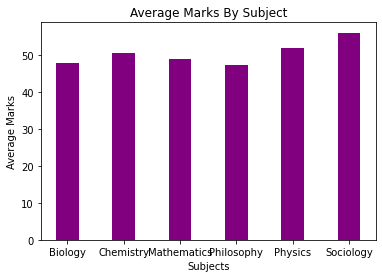

In [11]:
import matplotlib.pyplot as plt

Subjects = list(groupedData.keys())
print(Subjects)

AverageMarks = []
for key in Subjects:
  AverageMarks.append(groupedData[key])
print(AverageMarks)

plt.bar(Subjects, AverageMarks, color = 'purple', width = 0.4)
 
plt.xlabel("Subjects")
plt.ylabel("Average Marks")
plt.title("Average Marks By Subject")
plt.show()

---
## Question 4
---

**Part A** - Import the file "CatData.csv" and preprocess it to remove any null values

In [12]:
import pandas as pd
catData = pd.read_csv("CatData.csv")
print(catData)

print("Number of Rows Before: ",catData.shape[0])
print("Number of rows containing null data:",catData.isnull().sum().sum())
catData.dropna(axis=0, inplace=True)
print("Number of rows containing null data after removal:",catData.isnull().sum().sum())
print("Number of Rows After: ",catData.shape[0])

     Tail Length (cm)  Mass (kg)
0                18.1      3.750
1                18.6      3.800
2                19.5      3.250
3                19.3      3.450
4                19.0      3.650
..                ...        ...
337              20.7      4.000
338              20.2      3.400
339              19.3      3.775
340              21.0      4.100
341              19.8      3.775

[342 rows x 2 columns]
Number of Rows Before:  342
Number of rows containing null data: 0
Number of rows containing null data after removal: 0
Number of Rows After:  342


**Part B** - Identify the independant and dependant variables (comment answer below)

In [13]:
# dependant variable: Mass (kg)
# independant variable: Tail Length (cm)

**Part C** - Create a linear regression model using sklearn and fit it to the data you just imported


In [14]:
from sklearn.linear_model import LinearRegression

data, target = catData[["Tail Length (cm)"]], catData["Mass (kg)"]

linear_regression = LinearRegression()
linear_regression.fit(data, target)

LinearRegression()

**Part D** - Print the values for slope and y-intercept

In [15]:
slope = linear_regression.coef_[0]
print("Slope/Gradient:", slope)

intercept = linear_regression.intercept_
print("Intercept:", intercept)

Slope/Gradient: 0.49685566406100085
Intercept: -5.780831358077062


**Part E** - Plot a scatter graph of the original data and a regression line on the same figure (example with dummy data shown below)

![](https://drive.google.com/uc?export=view&id=1o_NAsNjfx7zAh9m-UjvWB3rta6uraKdY)

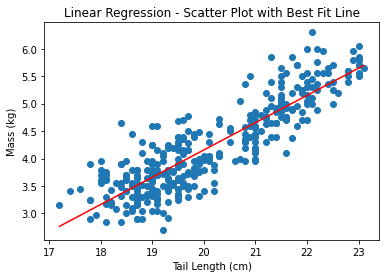

In [24]:
import matplotlib.pyplot as plt
import numpy as np

xVals, yVals = catData["Tail Length (cm)"], catData["Mass (kg)"]

plt.scatter(xVals, yVals)

x_range = np.linspace(xVals.min(), xVals.max(), num=2)
y_range = (slope * x_range + intercept) # y = mx + c 
plt.plot(x_range, y_range, color="red")

plt.xlabel("Tail Length (cm)")
plt.ylabel("Mass (kg)")
plt.title("Linear Regression - Scatter Plot with Best Fit Line")
plt.show()